# MotionCLIP Anomaly detection using class distribution

In [2]:
import torch
import clip
import os
from src.utils.action_label_to_idx import action_label_to_idx
import sys
import torch.nn.functional as F
from tqdm import tqdm
from src.models.architectures.transformer import Encoder_TRANSFORMER, Decoder_TRANSFORMER
from src.models.modeltype.motionclip import MOTIONCLIP
from src.utils.get_model_and_data import get_model_and_data
from src.parser.visualize import parser
from src.utils.misc import load_model_wo_clip
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D
from collections import defaultdict
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import seaborn as sns

In [3]:
os.environ["CLIP_CACHE_DIR"] = "D:/clip_cache"
device = "cuda" if torch.cuda.is_available() else "cpu"

### Create text embeddings of the classes

In [4]:
def encode_class(classes_60):
    class_embeddings = {}
    clip_model, preprocess = clip.load("ViT-B/32", device=device, download_root=os.environ["CLIP_CACHE_DIR"])
    for classes in classes_60:
        with torch.no_grad():
            tokens = clip.tokenize(classes).to(device)

            text_embeddings = clip_model.encode_text(tokens)

            text_embeddings = text_embeddings / text_embeddings.norm(dim=-1, keepdim=True)
            class_embeddings[classes] = text_embeddings
    return class_embeddings

### Get motion embeddings

In [ ]:
print("Current working dir:", os.getcwd())

ckpt_path = "../classes-model/checkpoint_0200.pth.tar"

sys.argv = ["program", "--cuda", ckpt_path]
parameters, folder, checkpointname, epoch = parser(checkpoint=True)
parameters["device"] = device
parameters["dataset"] = "babel"
parameters["datapath"] = "data/amass_db/babel_30fps_db.pt" #this one has 384 unique classes
parameters["babel_dir"] = "data/babel_v1.0_release"
parameters["target_fps"] = 30
parameters['only_60_classes'] = False


assert os.path.exists("data/amass_db")

model, datasets = get_model_and_data(parameters, split="train")
ckpt_path = os.path.join(folder, checkpointname)
state_dict = torch.load(ckpt_path, map_location=device)
load_model_wo_clip(model, state_dict)

for p in model.parameters():
    p.requires_grad = False
model.eval()

Current working dir: d:\Delft\Uni\Thesis\MotionCLIP_experiment\MotionCLIP
datapath used by amass is [data/amass_db/babel_30fps_train.pt]
datapath used by amass is [data/amass_db/babel_30fps_train.pt]


d:\anaconda3\envs\motionclip\lib\site-packages\torch\nn\modules\transformer.py:307: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(f"enable_nested_tensor is True, but self.use_nested_tensor is False because {why_not_sparsity_fast_path}")
C:\Users\meenakshi\AppData\Local\Temp\ipykernel_26936\764639828.py:22: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be a

MOTIONCLIP(
  (encoder): Encoder_TRANSFORMER(
    (skelEmbedding): Linear(in_features=150, out_features=512, bias=True)
    (sequence_pos_encoder): PositionalEncoding(
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (seqTransEncoder): TransformerEncoder(
      (layers): ModuleList(
        (0-7): 8 x TransformerEncoderLayer(
          (self_attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
          )
          (linear1): Linear(in_features=512, out_features=1024, bias=True)
          (dropout): Dropout(p=0.1, inplace=False)
          (linear2): Linear(in_features=1024, out_features=512, bias=True)
          (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
          (dropout1): Dropout(p=0.1, inplace=False)
          (dropout2): Dropout(p=0.1, inplace=False)
        )
      )
    )
  )
  (decoder): Decoder_TRANSFO

In [ ]:
all_latents, all_labels = [], []
with torch.no_grad():
    for i, sample in enumerate(tqdm(datasets["train"])):
        if sample is None or "inp" not in sample:
            continue
        motion = sample["inp"].to(device).unsqueeze(0)
        label  = sample["y"]             
        T = motion.shape[-1]
        mask = torch.ones(1, T, dtype=torch.bool, device=device)
        batch = {"x": motion, "y": torch.tensor([label], dtype=torch.long, device=device), "mask": mask}

        z_out = model.encoder(batch)  
        z_p = z_out["mu"]     
        z_p = z_p / z_p.norm(dim=-1, keepdim=True)  
        all_latents.append(z_p.cpu())
        all_labels.append(label)
print(torch.unique(torch.tensor(all_labels)))

100%|██████████| 20112/20112 [06:59<00:00, 47.97it/s]

tensor([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,  13,
         14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,  26,  27,
         28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,  39,  40,  41,
         42,  43,  44,  45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,
         56,  57,  58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,
         70,  71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
         84,  85,  86,  87,  88,  89,  90,  92,  93,  94,  95,  96,  98,  99,
        100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
        114, 115, 116, 117, 118, 119])


In [5]:
# torch.save({
#     "latents": all_latents,
#     "labels": all_labels
# }, "motion_latents.pt")


data = torch.load("motion_latents.pt")

all_latents = data["latents"]
all_labels = data["labels"]

C:\Users\meenakshi\AppData\Local\Temp\ipykernel_21068\236517031.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load("motion_latents.pt")


### Get the chosen text embedding

In [6]:
def get_embedding_by_label(target_label):
    all_labels_tensor = torch.tensor(all_labels)
    
    indices = (all_labels_tensor == target_label).nonzero(as_tuple=True)[0]
    
    if len(indices) > 0:
        embeddings = [all_latents[i] for i in indices]
        return embeddings
    else:
        print(f"Label {target_label} not found!")
        return None

### Check similarity

In [7]:
def detect_anomaly(label, threshold=0.69):
    classes_60 = list(action_label_to_idx.keys())[:60]  
    class_embeddings = encode_class(classes_60)  
    
    motion_embedding = get_embedding_by_label(label)  
    
    if motion_embedding is None:
            print(f"Label {label} not found! Skipping...")
            return False, _, "No motion found"
    similarities = {}
    highest_similarity = -1  
    most_similar_class = None  
    
    for class_name, class_embedding in class_embeddings.items():
        similarity = cosine_similarity(motion_embedding[0].cpu().detach().numpy(), class_embedding.cpu().detach().numpy())
        similarities[class_name] = similarity
        
        if similarity > highest_similarity:
            highest_similarity = similarity
            most_similar_class = class_name
    
    max_similarity = highest_similarity
    
    if max_similarity > threshold:
        return False, max_similarity, most_similar_class
    else:
        return True, max_similarity, most_similar_class


In [11]:
def detect_anomaly_seen(label, threshold):
    classes_60 = list(action_label_to_idx.keys())[:60] 
    class_embeddings = encode_class(classes_60)
    
    motion_embedding = get_embedding_by_label(label) 
    
    if motion_embedding is None:
            print(f"Label {label} not found! Skipping...")
            return False, _, "No motion found"
    similarities = {}
    highest_similarity = -1  
    most_similar_class = None  
    
    for class_name, class_embedding in class_embeddings.items():
        similarity = cosine_similarity(motion_embedding[0].cpu().detach().numpy(), class_embedding.cpu().detach().numpy())
        similarities[class_name] = similarity
        
        if similarity > highest_similarity:
            highest_similarity = similarity
            most_similar_class = class_name
    
    max_similarity = highest_similarity
    
    if max_similarity > threshold:
        return False, max_similarity, most_similar_class
    else:
        return True, max_similarity, most_similar_class


In [61]:
motion_label = 93
anomaly, similarity_score, most_simlar_classname = detect_anomaly(motion_label)

if anomaly:
    print("Anomaly detected", similarity_score, most_simlar_classname)
else: 
    print("No anomaly detected", similarity_score, most_simlar_classname)

Anomaly detected [[0.75876784]] gesture


# Plot PCA

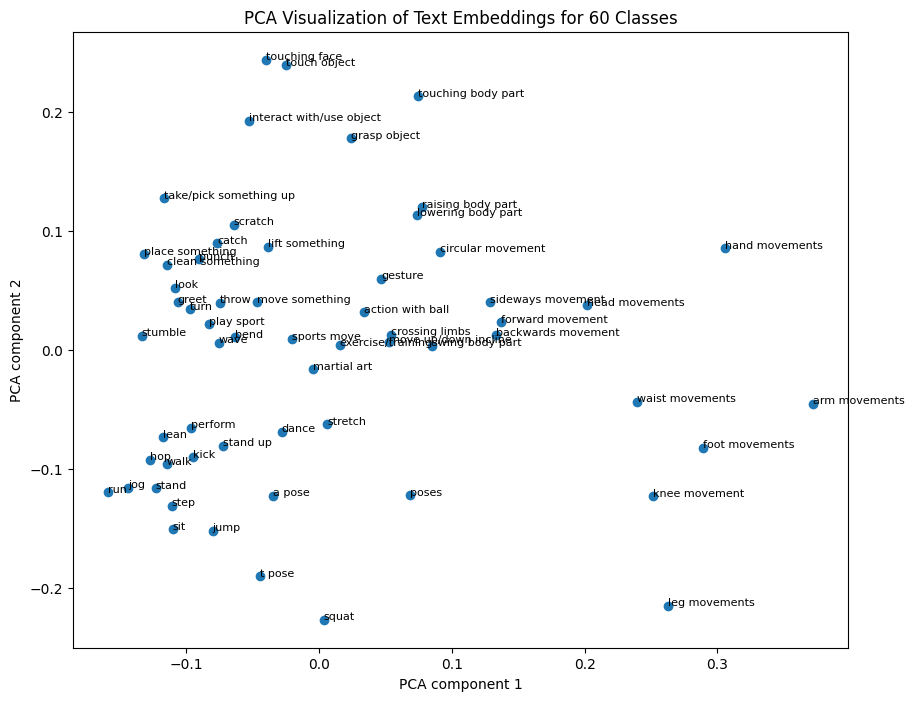

In [ ]:
embeddings = []
class_labels = []
classes_60 = list(action_label_to_idx.keys())[:60]  
class_embeddings = encode_class(classes_60)

for class_name, class_embedding in class_embeddings.items():
    embeddings.append(class_embedding.cpu().detach().numpy()) 
    class_labels.append(class_name)

embeddings = np.vstack(embeddings)

pca = PCA(n_components=2)  
embeddings_pca = pca.fit_transform(embeddings)

plt.figure(figsize=(10, 8))

plt.scatter(embeddings_pca[:, 0], embeddings_pca[:, 1])

for i, class_name in enumerate(class_labels):
    plt.annotate(class_name, (embeddings_pca[i, 0], embeddings_pca[i, 1]), fontsize=8)

plt.title("PCA Visualization of Text Embeddings for 60 Classes")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")

plt.show()


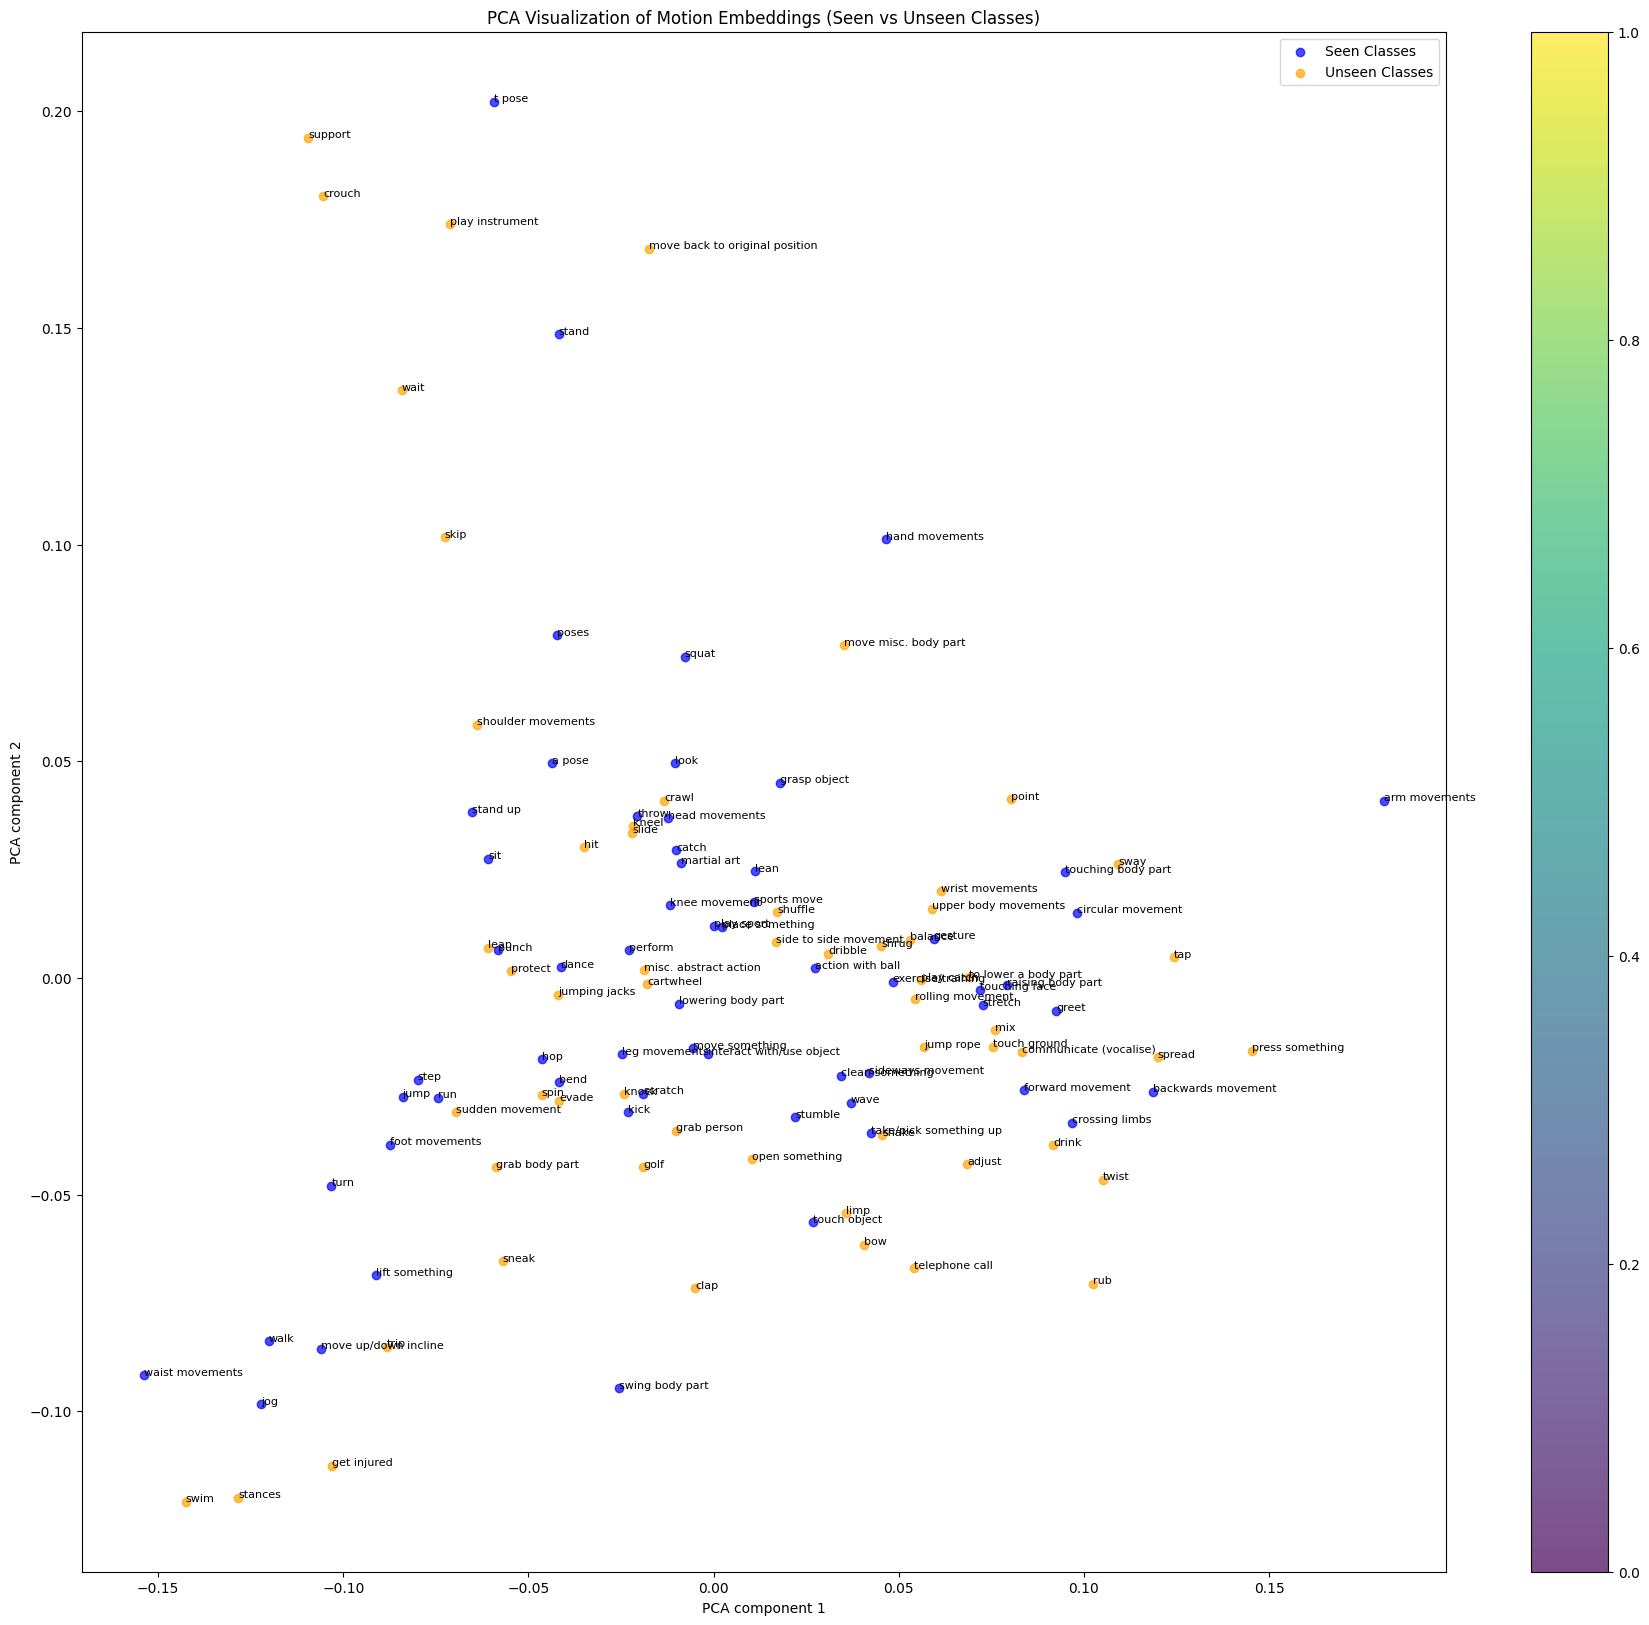

In [ ]:
# for motion data
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


idx_to_action_label = {v: k for k, v in action_label_to_idx.items()}

first_motion_embeddings = []
first_motion_labels = []

unique_labels = np.unique(all_labels)  

for label in unique_labels:
    first_index = np.where(np.array(all_labels) == label)[0][0]
    
    first_motion_embeddings.append(all_latents[first_index].cpu().detach().numpy())
    first_motion_labels.append(label)

first_motion_embeddings = np.vstack(first_motion_embeddings)

pca = PCA(n_components=2)  
motion_embeddings_pca = pca.fit_transform(first_motion_embeddings)

plt.figure(figsize=(22, 20))

plt.scatter(motion_embeddings_pca[:60, 0], motion_embeddings_pca[:60, 1], c='blue', label='Seen Classes', alpha=0.7)
plt.scatter(motion_embeddings_pca[60:, 0], motion_embeddings_pca[60:, 1], c='orange', label='Unseen Classes', alpha=0.7)

for i, label in enumerate(first_motion_labels):
    action_label = idx_to_action_label[label]  
    plt.annotate(action_label, (motion_embeddings_pca[i, 0], motion_embeddings_pca[i, 1]), fontsize=8)

plt.colorbar()

plt.title("PCA Visualization of Motion Embeddings (Seen vs Unseen Classes)")
plt.xlabel("PCA component 1")
plt.ylabel("PCA component 2")

plt.legend()

plt.show()


In [ ]:
def detect_unseen_anomalies(unseen_classes, threshold):    
    misclassified = defaultdict(list)
    correct_predictions = 0
    total_predictions = len(unseen_classes)

    ground_truth = [] 
    predicted = []
    for unseen_class in tqdm(unseen_classes):
        label = unseen_class  
        is_anomaly, max_similarity, most_similar_class = detect_anomaly(label, threshold)
        
        ground_truth.append(1)
        if is_anomaly:
            correct_predictions += 1
            predicted.append(1)
        else:
            misclassified[unseen_class].append(most_similar_class)
            predicted.append(0)


    accuracy = correct_predictions / total_predictions
    precision = precision_score(ground_truth, predicted)
    recall = recall_score(ground_truth, predicted)
    f1 = f1_score(ground_truth, predicted)

    cm = confusion_matrix(ground_truth, predicted)

    fpr, tpr, thresholds = roc_curve(ground_truth, predicted)
    roc_auc = auc(fpr, tpr)

    return accuracy, misclassified, precision, recall, f1, cm, fpr, tpr, roc_auc

unseen_classes = range(60, 120) 

accuracy, misclassified, precision, recall, f1, cm, fpr, tpr, roc_auc = detect_unseen_anomalies(unseen_classes)

# Accuracy, Precision, Recall and F1-score
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Confusion Matrix plot
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Print misclassifications
if misclassified:
    for unseen_class, mapped_classes in misclassified.items():
        print(f"Unseen class '{unseen_class}' mapped to seen class(es): {', '.join(mapped_classes)}")

 37%|███▋      | 22/60 [03:01<06:16,  9.91s/it]

: 

Processing unseen classes:  53%|█████▎    | 32/60 [02:48<02:31,  5.41s/it]

Label 91 not found!
Label 91 not found! Skipping...


Processing unseen classes:  63%|██████▎   | 38/60 [03:22<02:02,  5.55s/it]

Label 97 not found!
Label 97 not found! Skipping...


Processing unseen classes: 100%|██████████| 60/60 [05:23<00:00,  5.40s/it]

Accuracy: 47.50%
Precision: 0.49
Recall: 0.92
F1-Score: 0.64


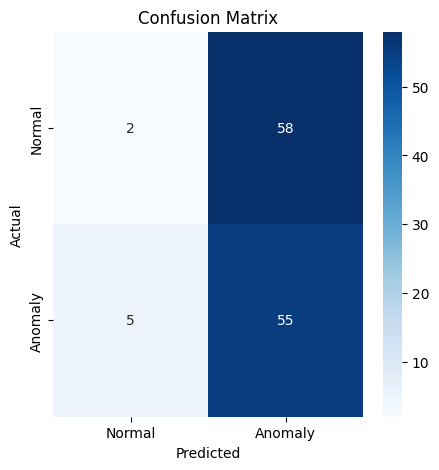

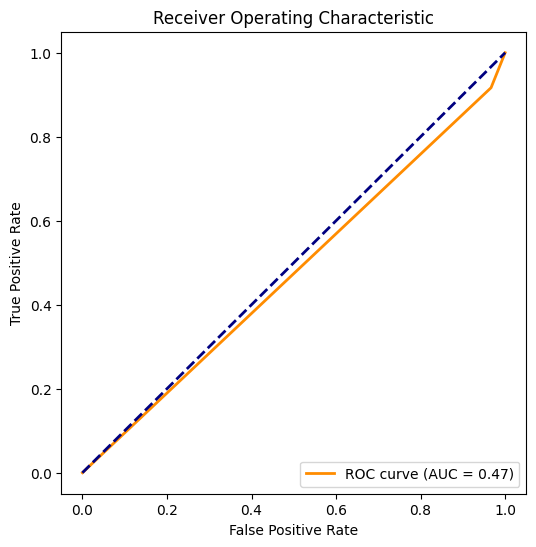

Seen class '1' misclassified as anomaly class(es): stand
Seen class '2' misclassified as anomaly class(es): gesture
Seen class '3' misclassified as anomaly class(es): step
Seen class '4' misclassified as anomaly class(es): gesture
Seen class '5' misclassified as anomaly class(es): arm movements
Seen class '6' misclassified as anomaly class(es): t pose
Seen class '7' misclassified as anomaly class(es): walk
Seen class '8' misclassified as anomaly class(es): backwards movement
Seen class '9' misclassified as anomaly class(es): backwards movement
Seen class '10' misclassified as anomaly class(es): stand
Seen class '11' misclassified as anomaly class(es): gesture
Seen class '12' misclassified as anomaly class(es): dance
Seen class '13' misclassified as anomaly class(es): sideways movement
Seen class '14' misclassified as anomaly class(es): gesture
Seen class '15' misclassified as anomaly class(es): backwards movement
Seen class '16' misclassified as anomaly class(es): dance
Seen class '17'

In [14]:
def detect_anomalies(seen_classes, unseen_classes, threshold):
    misclassified_seen = defaultdict(list)
    misclassified_unseen = defaultdict(list)
    correct_predictions = 0
    total_predictions = len(seen_classes) + len(unseen_classes)

    ground_truth = []  
    predicted = []   
    
    for seen_class in tqdm(seen_classes, desc="Processing seen classes"):
        label = seen_class
        is_anomaly, max_similarity, most_similar_class = detect_anomaly(label, threshold)
        
        ground_truth.append(0) 
        if is_anomaly:
            misclassified_seen[seen_class].append(most_similar_class)
            predicted.append(1)
        else:
            correct_predictions += 1
            predicted.append(0)
    
    for unseen_class in tqdm(unseen_classes, desc="Processing unseen classes"):
        label = unseen_class
        is_anomaly, max_similarity, most_similar_class = detect_anomaly(label, threshold)
        
        ground_truth.append(1)  
        if is_anomaly:
            correct_predictions += 1
            predicted.append(1)
        else:
            misclassified_unseen[unseen_class].append(most_similar_class)
            predicted.append(0)

    accuracy = correct_predictions / total_predictions
    precision = precision_score(ground_truth, predicted)
    recall = recall_score(ground_truth, predicted)
    f1 = f1_score(ground_truth, predicted)

    cm = confusion_matrix(ground_truth, predicted)

    fpr, tpr, thresholds = roc_curve(ground_truth, predicted)
    roc_auc = auc(fpr, tpr)

    return accuracy, misclassified_seen,misclassified_unseen, precision, recall, f1, cm, fpr, tpr, roc_auc

seen_classes = range(0, 60)  
unseen_classes = range(60, 120)  

accuracy, misclassified_seen,misclassified_unseen, precision, recall, f1, cm, fpr, tpr, roc_auc = detect_anomalies(seen_classes, unseen_classes, 0.78)

# Accuracy, Precision, Recall and F1-score
print(f"Accuracy: {accuracy * 100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")

# Confusion Matrix plot
plt.figure(figsize=(5, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve plot
plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()

# Print misclassifications
if misclassified_seen:
    for seen_class, mapped_classes in misclassified_seen.items():
        print(f"Seen class '{seen_class}' misclassified as anomaly class(es): {', '.join(mapped_classes)}")
if misclassified_unseen:
    for unseen_class, mapped_classes in misclassified_unseen.items():
        print(f"Unseen class '{unseen_class}' misclassified as normal class(es): {', '.join(mapped_classes)}")